# Avance 1. Análisis Exploratorio de Datos (EDA)

**Sistema Inteligente para la Optimización de Operaciones de Transporte mediante Inteligencia Artificial aplicada al Análisis Predictivo de Datos GPS**

Maestría en Inteligencia Artificial Aplicada, TC5035, Equipo 56

**Equipo:**
- Alejandra Guadalupe Larrañaga Altamirano, A01794334
- Mario Alberto Guillén De La Torre, A01796701
- Andrea Kimberly Fray Tamayo, A01797168

**Fecha:** 4 de octubre de 2026

---

**Importante antes de entregar:** este notebook debe ejecutarse de principio a fin de manera **SECUENCIAL** (Kernel → Restart & Run All) antes de subir el link al repositorio y entregar la tarea. Si lo corres en Google Colab sin tener el repo clonado/montado, la celda de carga de datos te va a pedir subir los archivos manualmente, ver sección 0.

**Fuente de verdad del esquema de datos:** [`docs/data-schema.md`](../docs/data-schema.md) del repo. Cualquier duda sobre qué significa una columna, o qué variables NO se pueden usar como input de un modelo (regla de data leakage), está documentada ahí.

## 0. Configuración y carga de datos

Cargamos ambas fuentes por separado antes de unirlas, para poder comparar `real` vs `synthetic` explícitamente en el análisis bivariado. La función de carga funciona tanto si corres el notebook dentro del repo clonado (rutas relativas normales) como si lo abres suelto en Colab (te pedirá subir el archivo manualmente).

In [3]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.feature_selection import mutual_info_regression

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

IN_COLAB = "google.colab" in sys.modules

# Nombre confirmado del archivo que exporta SyntheticGeneration.ipynb
#SYNTHETIC_PATH = "../data/synthetic/synthetic_trips.csv"
SYNTHETIC_PATH = "../data/synthetic/synthetic_trips.csv.gz"
REAL_PATH = "../data/raw/trips_real_export.csv"


def cargar_datos(path, nombre):
    """Lee el CSV desde la ruta del repo clonado. Si no existe y estamos en
    Colab (notebook abierto suelto, sin el repo), pide subirlo manualmente
   , así un Restart & Run All no truena solo por el entorno."""
    if os.path.exists(path):
        return pd.read_csv(path)
    if IN_COLAB:
        print(f"No se encontró '{path}' localmente. Sube el archivo '{nombre}':")
        from google.colab import files
        uploaded = files.upload()
        fname = list(uploaded.keys())[0]
        return pd.read_csv(fname)
    raise FileNotFoundError(
        f"No se encontró {path}. Corre este notebook desde dentro del repo "
        f"clonado (carpeta notebooks/), o ábrelo en Colab para que te pida "
        f"subir el archivo manualmente."
    )


df_synthetic = cargar_datos(SYNTHETIC_PATH, "dataset sintético de trips")
df_real = cargar_datos(REAL_PATH, "export de trips reales")

assert "data_source" in df_synthetic.columns, "Falta data_source en el dataset sintético"
assert "data_source" in df_real.columns, "Falta data_source en el dataset real"

# Normalizar zonas: el dataset sintético trae origin_zone_id/destination_zone_id
# (números), no los nombres, los traducimos aquí usando el catálogo del repo,
# así ambas fuentes terminan con las mismas columnas origin_zone/destination_zone
# (texto) sin importar cómo las exportó cada quien.
ZONES_PATH = "../docs/zones.csv"
if os.path.exists(ZONES_PATH):
    zones_lookup = pd.read_csv(ZONES_PATH).set_index("id")["name"]
    for d in [df_synthetic, df_real]:
        if "origin_zone_id" in d.columns and "origin_zone" not in d.columns:
            d["origin_zone"] = d["origin_zone_id"].map(zones_lookup)
        if "destination_zone_id" in d.columns and "destination_zone" not in d.columns:
            d["destination_zone"] = d["destination_zone_id"].map(zones_lookup)

df = pd.concat([df_real, df_synthetic], ignore_index=True)

assert df["origin_zone"].notna().any(), (
    "origin_zone vino vacío en todas las filas, revisa que df_real tenga "
    "origin_zone u origin_zone_id (ver instrucciones para regenerar el export real)."
)

# utc=True normaliza todas las fechas a UTC tz-aware, sea que el CSV traiga "Z"
# (synthetic) o fechas sin timezone (real export), sin esto, pd.concat
# mezcla tz-aware con tz-naive y el resultado deja de comportarse como
# datetime real (se vuelve dtype object, y .dt deja de funcionar).
for col in ["started_at", "ended_at"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], utc=True, format="mixed")

print(f"Reales: {len(df_real)} | Sintéticos: {len(df_synthetic)} | Total: {len(df)}")
df.head()

Reales: 7 | Sintéticos: 436800 | Total: 436807


,vehicle_id,started_at,ended_at,duration_seconds,distance_km,average_speed,max_speed,stops_count,stopped_seconds,data_source,origin_zone,destination_zone,origin_zone_id,destination_zone_id
0,1,2026-09-28 15:05:32+00:00,2026-09-28 16:56:24+00:00,6652,9.370,15.320394,49.000018,3.0,337.0,real,Cancun,Cancun,NaN,NaN
1,1,2026-09-28 18:14:30+00:00,2026-09-28 19:09:33+00:00,3303,3.809,12.730005,45.000016,4.0,273.0,real,Cancun,Cancun,NaN,NaN
2,1,2026-09-29 16:39:43+00:00,2026-09-29 17:02:45+00:00,1382,3.665,15.077425,44.000016,3.0,143.0,real,Cancun,Cancun,NaN,NaN
3,1,2026-09-25 16:29:37+00:00,2026-09-25 16:38:38+00:00,541,2.643,17.312506,43.000016,0.0,0.0,real,Cancun,Cancun,NaN,NaN
4,1,2026-09-25 18:24:35+00:00,2026-09-25 19:38:06+00:00,4411,7.208,13.770786,52.000019,5.0,802.0,real,Cancun,Cancun,NaN,NaN


## 1. Estructura de los datos

*(Criterio de rúbrica, 20 pts: forma y tipos de datos, estadísticas descriptivas de todas las variables, frecuencia de clases en categóricas, valores faltantes identificados.)*

In [5]:
print("Forma del dataset:", df.shape)
print()
df.dtypes

Forma del dataset: (436807, 14)



vehicle_id                          object
started_at             datetime64[ns, UTC]
ended_at               datetime64[ns, UTC]
duration_seconds                     int64
distance_km                        float64
average_speed                      float64
max_speed                          float64
stops_count                        float64
stopped_seconds                    float64
data_source                         object
origin_zone                         object
destination_zone                    object
origin_zone_id                     float64
destination_zone_id                float64
dtype: object

In [6]:
df.describe()

,duration_seconds,distance_km,average_speed,max_speed,stops_count,stopped_seconds,origin_zone_id,destination_zone_id
count,436807.000000,436807.000000,7.000000,7.000000,7.000000,7.000000,436800.000000,436800.000000
mean,6441.750869,115.488079,16.318056,51.000019,4.714286,406.000000,14.192308,14.192308
std,4511.351737,98.252719,3.544579,9.345234,4.029652,379.276504,7.874111,7.874111
min,358.000000,1.660000,12.730005,43.000016,0.000000,0.000000,1.000000,1.000000
25%,2741.500000,38.251000,14.424105,44.500016,3.000000,188.000000,7.000000,7.000000
50%,5514.000000,83.832000,15.320394,49.000018,4.000000,273.000000,14.500000,14.500000
75%,8726.000000,157.225000,16.882714,53.000019,5.000000,569.500000,21.000000,21.000000
max,23449.000000,419.835000,23.562359,70.000025,13.000000,1054.000000,27.000000,27.000000


In [7]:
df.describe(include=["object", "category"])

,vehicle_id,data_source,origin_zone,destination_zone
count,436807,436807,436807,436807
unique,1739,2,26,26
top,syn_975,synthetic,Cancun,Cancun
freq,327,436800,16807,16807


In [8]:
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]

if missing.empty:
    print("No hay valores faltantes en este punto del pipeline.")
else:
    missing_pct = (missing / len(df) * 100).round(2)
    display(pd.DataFrame({"faltantes": missing, "%": missing_pct}))

# Nota: esto se vuelve a revisar DESPUÉS de la sección 1.5, porque derivar
# previous_trip_duration y historical_corridor_mean_duration va a introducir
# NaNs estructurales (primer viaje de cada vehículo/corredor) que todavía
# no existen aquí.

,faltantes,%
average_speed,436800,100.0
max_speed,436800,100.0
stops_count,436800,100.0
stopped_seconds,436800,100.0
origin_zone_id,7,0.0
destination_zone_id,7,0.0


In [9]:
for col in ["data_source", "origin_zone", "destination_zone"]:
    if col in df.columns:
        print(f"--- {col} ({df[col].nunique()} categorías) ---")
        print(df[col].value_counts())
        print()

--- data_source (2 categorías) ---
data_source
synthetic    436800
real              7
Name: count, dtype: int64

--- origin_zone (26 categorías) ---
origin_zone
Cancun              16807
Chetumal            16800
Chiquila            16800
Akumal              16800
Cozumel             16800
Maroma Beach        16800
Merida              16800
Kantenah            16800
Xpu Ha              16800
Chichen Itza        16800
Costa Mujeres       16800
Tankah              16800
Puerto Juarez       16800
Boca Paila          16800
Paamul              16800
Puerto Morelos      16800
Valladolid          16800
Tulum               16800
Tulum Hotel Zone    16800
Xcaret              16800
Playa Del Carmen    16800
Paraiso Beach       16800
Puerto Aventuras    16800
Playa Mujeres       16800
Playacar            16800
Calica              16800
Name: count, dtype: int64

--- destination_zone (26 categorías) ---
destination_zone
Cancun              16807
Playacar            16800
Costa Mujeres       16800

## 1.5 Derivación de variables

Estas columnas son features candidatas para el modelo (ver sección 4.4) pero no necesariamente vienen ya calculadas en el CSV crudo, se derivan aquí, una sola vez, antes de cualquier análisis que las use.

**Importante, mismo principio de leakage que ya aplicamos en el backend (`TripBuilderService`):** `previous_trip_duration` y `historical_corridor_mean_duration` deben calcularse ordenando por tiempo y usando solo información *anterior* a cada viaje (`.shift(1)` / `.expanding().shift(1)`), nunca el dataset completo de una sola vez, eso sería fuga de información hacia el pasado.

In [11]:
# Corredor como combinación origin→destination, se usa para el histórico
# por corredor y para medir su cardinalidad en la sección 4.3.
if "origin_zone" in df.columns and "destination_zone" in df.columns:
    df["corridor"] = df["origin_zone"] + " → " + df["destination_zone"]

# hour_of_day / day_of_week SIEMPRE se calculan aquí, en hora LOCAL de
# Cancún, nunca en UTC. started_at vive en UTC en todas las fuentes
# (real y sintética), pero un patrón de tráfico por hora solo tiene
# sentido en hora local (la hora pico es a las 6pm hora Cancún, no a
# las 6pm UTC). Se recalculan siempre, aunque el CSV ya traiga estas
# columnas (por ejemplo, el notebook de generación sintética de Mario
# las calcula en hora local también, pero por consistencia y para no
# depender de que ambos pipelines coincidan en la convención, las
# derivamos nosotros mismos una sola vez, aquí, para las dos fuentes.
local_time = df["started_at"].dt.tz_convert("America/Cancun")
df["hour_of_day"] = local_time.dt.hour
df["day_of_week"] = local_time.dt.dayofweek  # 0=lunes

# previous_trip_duration, viaje inmediatamente anterior del MISMO vehículo,
# ordenado por tiempo. IMPORTANTE: agrupamos por (data_source, vehicle_id),
# no solo vehicle_id, si un vehicle_id sintético coincide numéricamente con
# uno real, agrupar solo por vehicle_id mezclaría el historial de ambas
# fuentes, que son unidades distintas aunque compartan ID.
if "vehicle_id" in df.columns:
    df = df.sort_values("started_at")
    df["previous_trip_duration"] = df.groupby(["data_source", "vehicle_id"])["duration_seconds"].shift(1)

# historical_corridor_mean_duration, promedio histórico del corredor, SOLO
# con viajes anteriores (expanding + shift), y SOLO dentro de la misma fuente
# (data_source), mismo motivo que arriba: un corredor real y uno sintético
# no deberían promediarse juntos.
if "corridor" in df.columns:
    df = df.sort_values("started_at")
    df["historical_corridor_mean_duration"] = (
        df.groupby(["data_source", "corridor"])["duration_seconds"]
          .apply(lambda s: s.expanding().mean().shift(1))
          .reset_index(level=[0, 1], drop=True)
    )

nuevas_nan = df[["previous_trip_duration", "historical_corridor_mean_duration"]].isnull().sum()
print("NaN introducidos por derivación (esperado, primer viaje de cada vehículo/corredor DENTRO de su fuente):")
print(nuevas_nan)

NaN introducidos por derivación (esperado, primer viaje de cada vehículo/corredor DENTRO de su fuente):
previous_trip_duration               1739
historical_corridor_mean_duration     651
dtype: int64


## 2. Análisis univariante

*(Criterio de rúbrica, 20 pts: histogramas, boxplots, gráficos de barras, **según el tipo de dato y escala de medición** de cada variable, la rúbrica lo pide explícitamente, así que variables discretas/ordinales van con gráfico de barras, no histograma.)*

Asimetría (skew) de duration_seconds: 0.909


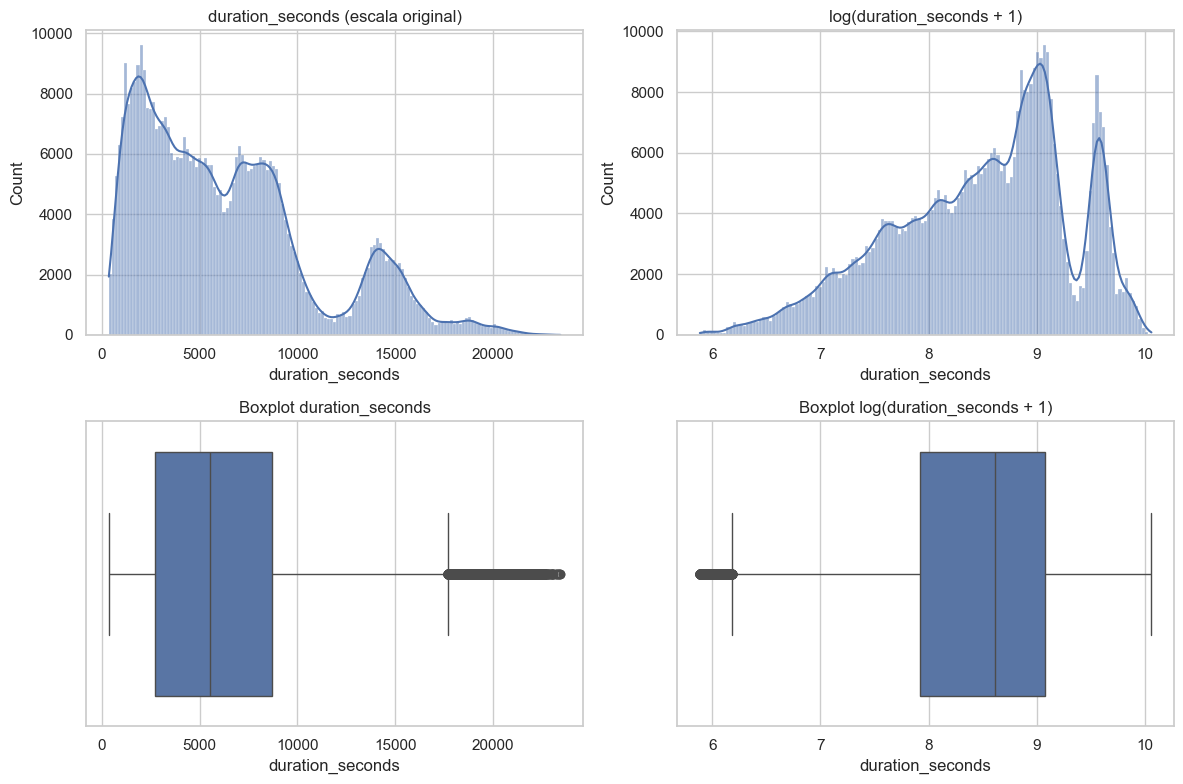

In [13]:
print("Asimetría (skew) de duration_seconds:", df["duration_seconds"].skew().round(3))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(df["duration_seconds"], kde=True, ax=axes[0, 0])
axes[0, 0].set_title("duration_seconds (escala original)")
sns.histplot(np.log1p(df["duration_seconds"]), kde=True, ax=axes[0, 1])
axes[0, 1].set_title("log(duration_seconds + 1)")
sns.boxplot(x=df["duration_seconds"], ax=axes[1, 0])
axes[1, 0].set_title("Boxplot duration_seconds")
sns.boxplot(x=np.log1p(df["duration_seconds"]), ax=axes[1, 1])
axes[1, 1].set_title("Boxplot log(duration_seconds + 1)")
plt.tight_layout()
plt.show()

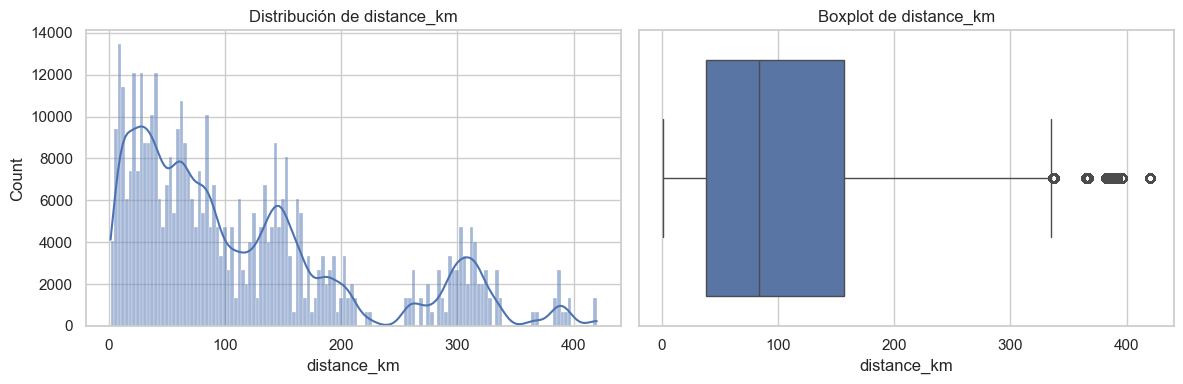

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["distance_km"], kde=True, ax=axes[0])
axes[0].set_title("Distribución de distance_km")
sns.boxplot(x=df["distance_km"], ax=axes[1])
axes[1].set_title("Boxplot de distance_km")
plt.tight_layout()
plt.show()

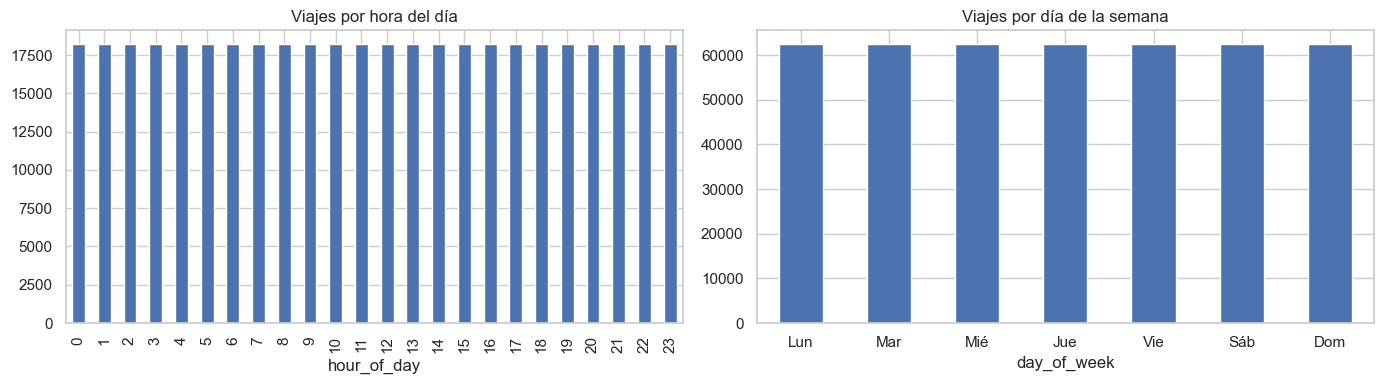

In [15]:
# hour_of_day y day_of_week son discretas/ordinales -> gráfico de barras,
# no histograma (así lo pide la rúbrica según la escala de medición).
# reindex(range(7)) asegura que los 7 días aparezcan aunque alguno tenga
# 0 viajes, sin esto, si falta un día, el gráfico tiene menos barras que
# etiquetas y la celda truena.
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df["hour_of_day"].value_counts().sort_index().plot(kind="bar", ax=axes[0])
axes[0].set_title("Viajes por hora del día")
dias = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]
df["day_of_week"].value_counts().reindex(range(7), fill_value=0).plot(kind="bar", ax=axes[1])
axes[1].set_xticklabels(dias, rotation=0)
axes[1].set_title("Viajes por día de la semana")
plt.tight_layout()
plt.show()

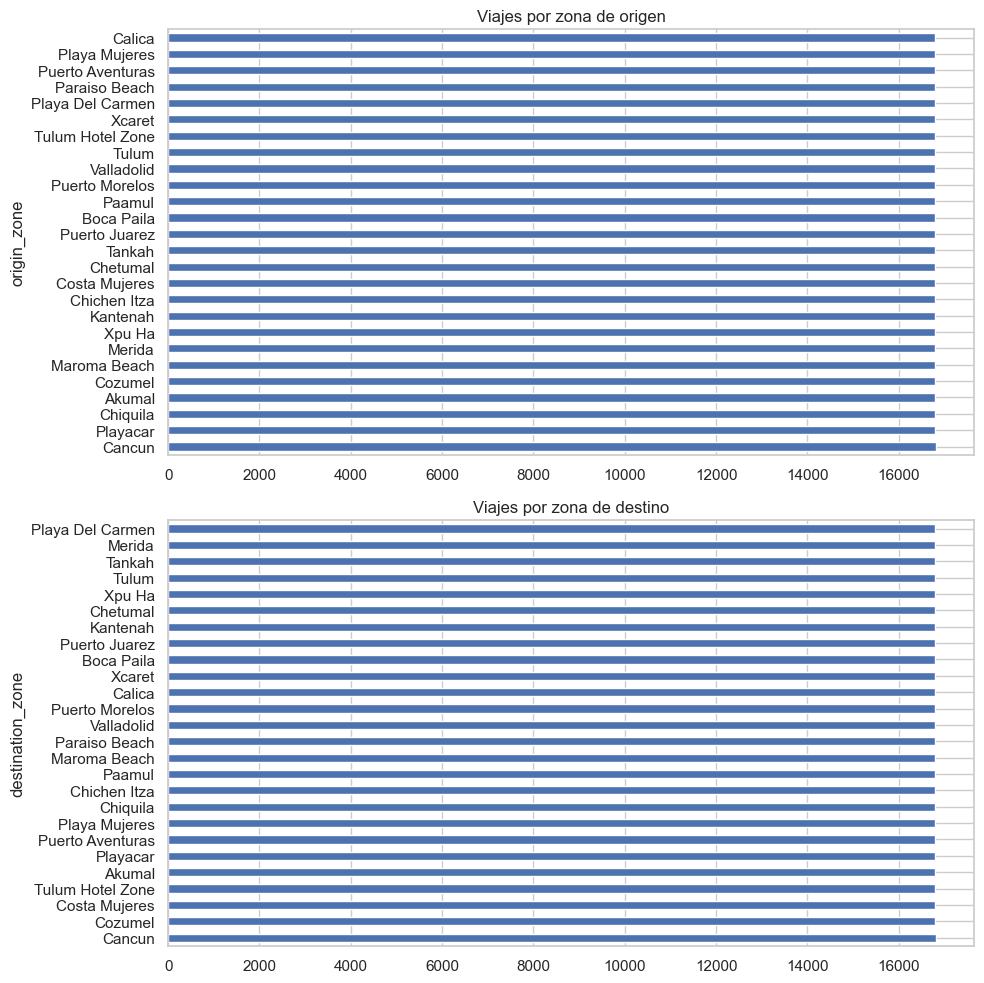

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(10, 10))
df["origin_zone"].value_counts().plot(kind="barh", ax=axes[0])
axes[0].set_title("Viajes por zona de origen")
df["destination_zone"].value_counts().plot(kind="barh", ax=axes[1])
axes[1].set_title("Viajes por zona de destino")
plt.tight_layout()
plt.show()

## 3. Análisis bi/multivariante

*(Criterio de rúbrica, 20 pts: correlación cuantitativa Y gráfica entre variables importantes, incluyendo la variable objetivo.)*

Excluidas de la matriz (existen solo en los viajes reales): ['average_speed', 'max_speed', 'stops_count', 'stopped_seconds']


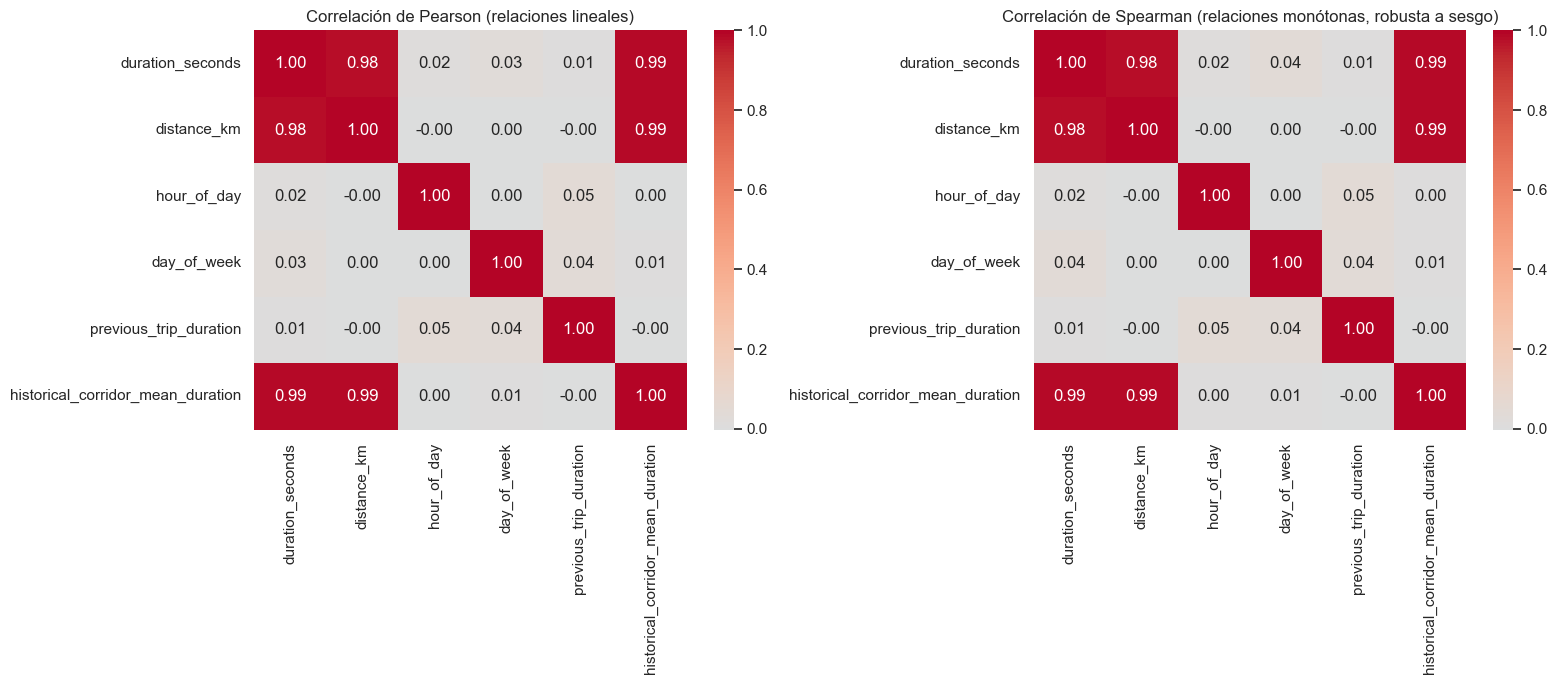

In [18]:
# Excluimos IDs: son identificadores, no magnitudes.
id_cols = [c for c in df.columns if c.endswith("_id")]
numeric_all = [c for c in df.select_dtypes(include=[np.number]).columns if c not in id_cols]

# average_speed, max_speed, stops_count y stopped_seconds solo existen en los 7 viajes
# reales (en los sinteticos estan vacias), asi que sus correlaciones se calcularian con
# 7 puntos y serian espurias. Se dejan fuera de la matriz.
numeric_cols = [c for c in numeric_all if df[c].notna().mean() > 0.5]
excluidas = [c for c in numeric_all if c not in numeric_cols]
print("Excluidas de la matriz (existen solo en los viajes reales):", excluidas)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.heatmap(df[numeric_cols].corr(method="pearson"), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[0])
axes[0].set_title("Correlación de Pearson (relaciones lineales)")
sns.heatmap(df[numeric_cols].corr(method="spearman"), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[1])
axes[1].set_title("Correlación de Spearman (relaciones monótonas, robusta a sesgo)")
plt.tight_layout()
plt.show()

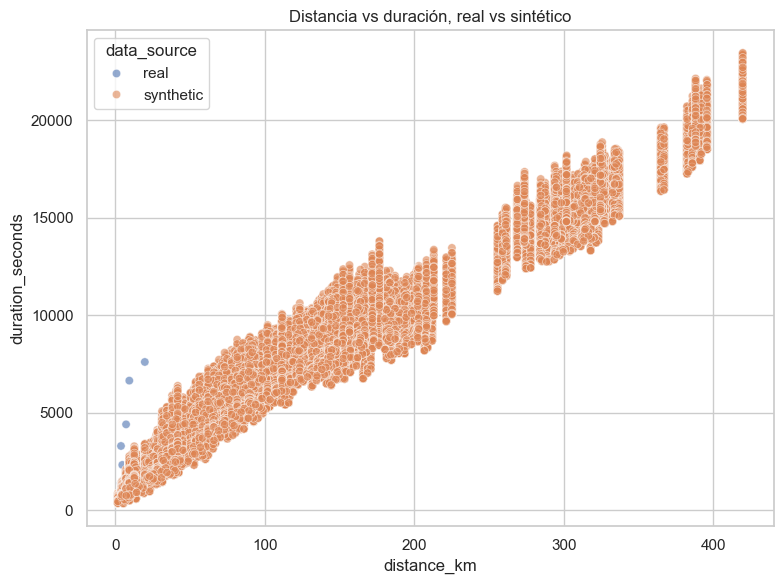

In [19]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="distance_km", y="duration_seconds", hue="data_source", alpha=0.6)
plt.title("Distancia vs duración, real vs sintético")
plt.tight_layout()
plt.show()

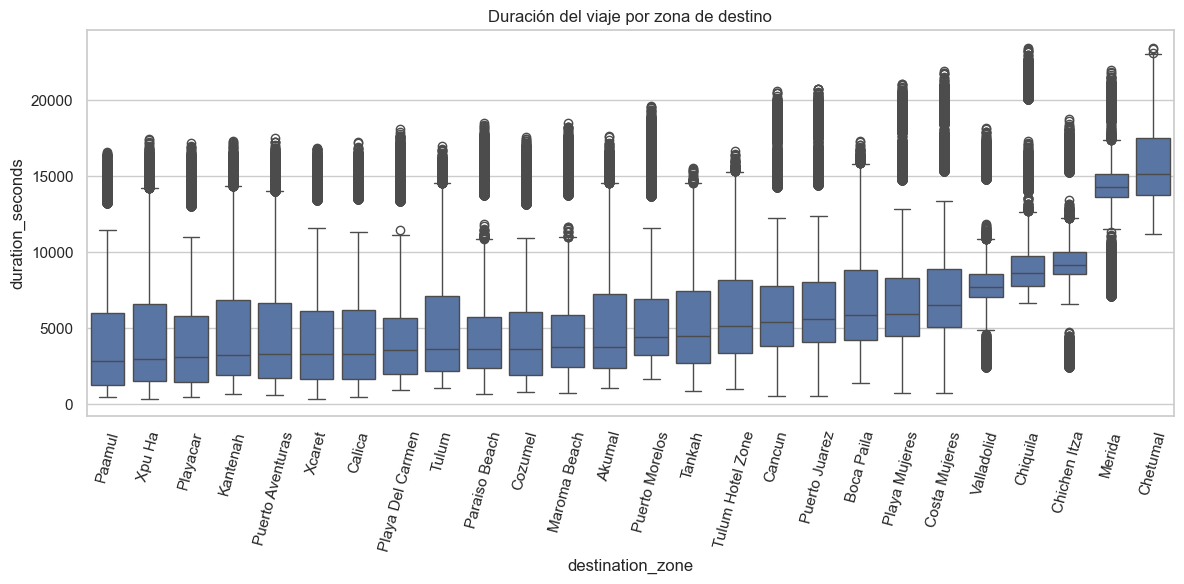

In [20]:
# Duración por zona de destino, parte GRÁFICA del análisis bivariado categórico
plt.figure(figsize=(12, 6))
order = df.groupby("destination_zone")["duration_seconds"].median().sort_values().index
sns.boxplot(data=df, x="destination_zone", y="duration_seconds", order=order)
plt.xticks(rotation=75)
plt.title("Duración del viaje por zona de destino")
plt.tight_layout()
plt.show()

In [21]:
# Parte CUANTITATIVA del análisis bivariado categórico (la rúbrica pide
# ambas, no solo la gráfica): tabla de mediana/IQR por zona + prueba de
# Kruskal-Wallis (no asume normalidad, apropiado si duration_seconds está sesgada).
tabla_zonas = df.groupby("destination_zone")["duration_seconds"].agg(
    mediana="median",
    q1=lambda s: s.quantile(0.25),
    q3=lambda s: s.quantile(0.75),
    n="count",
).sort_values("mediana")
display(tabla_zonas)

grupos = [g["duration_seconds"].values for _, g in df.groupby("destination_zone") if len(g) > 1]
if len(grupos) > 1:
    h_stat, p_value = stats.kruskal(*grupos)
    print(f"Kruskal-Wallis: H={h_stat:.2f}, p-value={p_value:.4f}")

,mediana,q1,q3,n
destination_zone,,,,
Paamul,2880.0,1284.75,6028.00,16800
Xpu Ha,2984.0,1506.75,6603.50,16800
Playacar,3117.0,1482.75,5787.00,16800
Kantenah,3253.0,1911.75,6884.25,16800
Puerto Aventuras,3302.0,1732.00,6644.75,16800
Xcaret,3302.0,1639.75,6110.00,16800
Calica,3322.5,1700.00,6199.50,16800
Playa Del Carmen,3547.0,2025.00,5682.00,16800
Tulum,3631.0,2210.00,7143.00,16800


Kruskal-Wallis: H=148482.63, p-value=0.0000


/var/folders/d2/_ymf9_q51mgdl52l2xg1sq1w0000gn/T/ipykernel_51987/2599515472.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(dias, rotation=0)


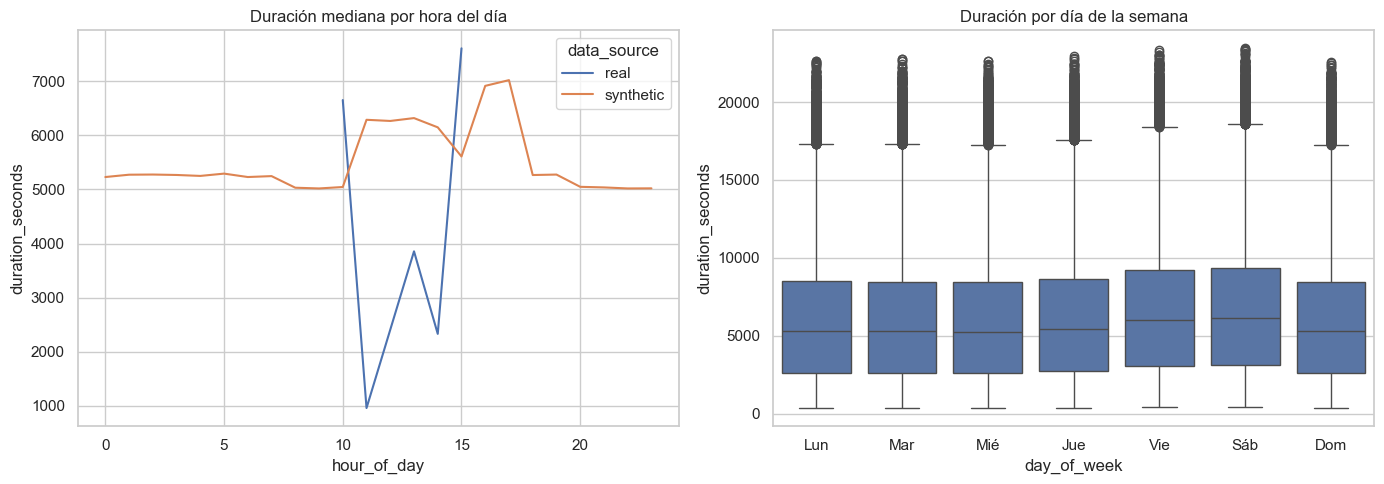

In [22]:
# Tendencia temporal, la rúbrica pregunta por esto explícitamente, y el
# generador sintético de Mario simula un factor de tráfico por hora/día,
# así que debería verse reflejado aquí.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(data=df, x="hour_of_day", y="duration_seconds", hue="data_source",
             estimator="median", errorbar=None, ax=axes[0])
axes[0].set_title("Duración mediana por hora del día")
sns.boxplot(data=df, x="day_of_week", y="duration_seconds", order=range(7), ax=axes[1])
axes[1].set_xticklabels(dias, rotation=0)
axes[1].set_title("Duración por día de la semana")
plt.tight_layout()
plt.show()

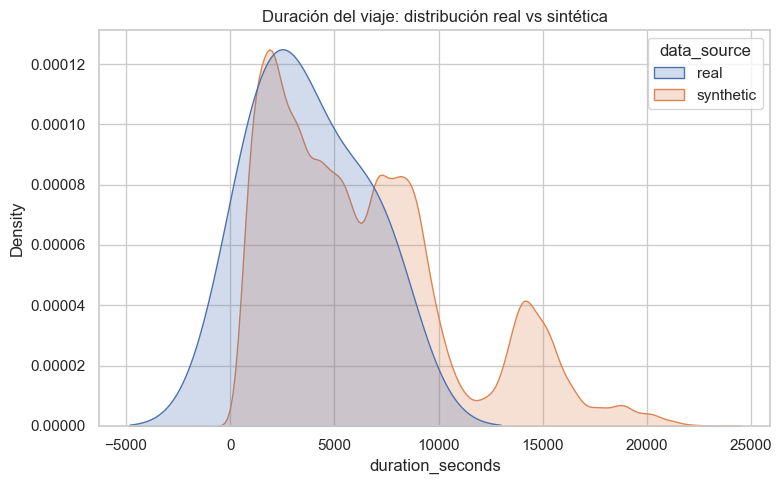

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.kdeplot(data=df, x="duration_seconds", hue="data_source", fill=True, common_norm=False, ax=ax)
ax.set_title("Duración del viaje: distribución real vs sintética")
plt.tight_layout()
plt.show()

## 4. Preprocesamiento

*(Criterio de rúbrica, 20 pts: ejecutar Y justificar las estrategias para valores faltantes, atípicos, y alta cardinalidad.)*

### 4.1 Valores faltantes

Revisamos otra vez, ahora que la sección 1.5 ya introdujo los NaN estructurales esperados (primer viaje por vehículo/corredor).

In [26]:
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]

if missing.empty:
    print("No hay valores faltantes.")
else:
    missing_pct = (missing / len(df) * 100).round(2)
    display(pd.DataFrame({"faltantes": missing, "%": missing_pct}))

# ¿Los faltantes se concentran en una fuente (real vs synthetic)?
display(df.groupby("data_source").apply(lambda g: g.isnull().mean().round(3)))

,faltantes,%
average_speed,436800,100.00
max_speed,436800,100.00
stops_count,436800,100.00
stopped_seconds,436800,100.00
previous_trip_duration,1739,0.40
historical_corridor_mean_duration,651,0.15
origin_zone_id,7,0.00
destination_zone_id,7,0.00


/var/folders/d2/_ymf9_q51mgdl52l2xg1sq1w0000gn/T/ipykernel_51987/574386683.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  display(df.groupby("data_source").apply(lambda g: g.isnull().mean().round(3)))


,vehicle_id,started_at,ended_at,duration_seconds,distance_km,average_speed,max_speed,stops_count,stopped_seconds,data_source,origin_zone,destination_zone,origin_zone_id,destination_zone_id,corridor,hour_of_day,day_of_week,previous_trip_duration,historical_corridor_mean_duration
data_source,,,,,,,,,,,,,,,,,,,
real,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.143,0.143
synthetic,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.004,0.001


In [27]:
# Decisión aplicada (justificación en el texto siguiente):
# imputamos con la MEDIANA del grupo (data_source, corridor) cuando existe
# suficiente historial; si no hay ninguno, con la mediana global. Es un
# default conservador, si deciden algo distinto (ej. dejar NaN para que
# el modelo lo maneje, o eliminar esas filas), reemplacen este bloque.
df_model = df.copy()

for col in ["previous_trip_duration", "historical_corridor_mean_duration"]:
    mediana_por_corredor = df_model.groupby(["data_source", "corridor"])[col].transform("median")
    df_model[col] = df_model[col].fillna(mediana_por_corredor)
    df_model[col] = df_model[col].fillna(df_model[col].median())

print("Faltantes después de imputar:")
print(df_model[["previous_trip_duration", "historical_corridor_mean_duration"]].isnull().sum())

Faltantes después de imputar:
previous_trip_duration               0
historical_corridor_mean_duration    0
dtype: int64


**Decisión.** Los únicos faltantes que afectan a variables del modelo son estructurales: `previous_trip_duration` (1,739 casos, 0.40%) e `historical_corridor_mean_duration` (651 casos, 0.15%) aparecen solo en el primer viaje de cada vehículo y de cada corredor, porque por definición no existe un viaje anterior. No son errores de captura ni se concentran en una fuente: son consecuencia directa de cómo se construyen las variables. Se imputan con la mediana del grupo (`data_source`, `corridor`) y, si el grupo no tiene valores, con la mediana global. Se prefirió imputar a eliminar filas para no perder ningún viaje real (solo hay 7), y se usó la mediana por ser robusta a la distribución sesgada de la duración. Como la mediana del grupo se calcula con todo el dataset, en el pipeline de entrenamiento del Avance 2 debe recalcularse únicamente con el conjunto de entrenamiento para no introducir fuga de información.

Las columnas `average_speed`, `max_speed`, `stops_count` y `stopped_seconds` están vacías en el 100% de los viajes sintéticos porque el generador no simula posiciones GPS. No se imputan: son resultado del viaje y ya están excluidas como features por la regla de leakage.

### 4.2 Valores atípicos

En datos GPS los atípicos típicos no son solo "duración muy larga", también hay saltos de señal: velocidades imposibles, viajes de pocos segundos, distancias absurdas para la duración registrada. Combinamos IQR (sobre la escala log, porque la duración está sesgada) con reglas de dominio.

In [30]:
# IQR sobre log, más robusto que IQR puro cuando la variable está sesgada
log_duration = np.log1p(df["duration_seconds"])
Q1, Q3 = log_duration.quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
outliers_iqr = df[(log_duration < lower) | (log_duration > upper)]

# Reglas de dominio: una velocidad máxima sobre 120 km/h o un viaje de menos de 60 s
# no son plausibles para un traslado terrestre y suelen indicar saltos de señal GPS.
UMBRAL_VELOCIDAD_MAX = 120  # km/h
UMBRAL_DURACION_MIN = 60    # segundos

outliers_dominio = df[
    (df.get("max_speed", 0) > UMBRAL_VELOCIDAD_MAX) |
    (df["duration_seconds"] < UMBRAL_DURACION_MIN)
]

print(f"Atípicos por IQR (log): {len(outliers_iqr)} de {len(df)}")
print(f"Atípicos por regla de dominio: {len(outliers_dominio)} de {len(df)}")
print()
print("Atípicos por fuente (importante: con solo 7 viajes reales, eliminar")
print("uno es perder ~14% de esa muestra, pensarlo dos veces antes de descartar):")
print(pd.concat([outliers_iqr, outliers_dominio]).drop_duplicates()["data_source"].value_counts())

Atípicos por IQR (log): 1230 de 436807
Atípicos por regla de dominio: 0 de 436807

Atípicos por fuente (importante: con solo 7 viajes reales, eliminar
uno es perder ~14% de esa muestra, pensarlo dos veces antes de descartar):
data_source
synthetic    1230
Name: count, dtype: int64


In [31]:
# ¿Qué corredores concentran los atípicos del IQR en escala log?
resumen = (outliers_iqr.groupby("corridor")["duration_seconds"]
           .agg(n="count", min_s="min", max_s="max")
           .sort_values("n", ascending=False))
display(resumen.head(10))
print(f"Corredores distintos con atípicos IQR: {len(resumen)}")
print(f"Límites del IQR en segundos -> inferior: {np.expm1(lower):.0f} | superior: {np.expm1(upper):.0f}")

,n,min_s,max_s
corridor,,,
Kantenah → Xpu Ha,503,358,482
Calica → Xcaret,451,370,482
Paamul → Calica,141,461,482
Xcaret → Calica,135,460,482


Corredores distintos con atípicos IQR: 4
Límites del IQR en segundos -> inferior: 482 | superior: 49537


In [32]:
# Decisión: NO acotar ni eliminar duration_seconds por IQR (ver texto siguiente).
# Solo se eliminan filas que violan reglas de dominio (0 casos con los umbrales actuales).
df_model = df_model.drop(index=outliers_dominio.index, errors="ignore")
print(f"Filas después de aplicar reglas de dominio: {len(df_model)} (de {len(df)} originales)")

Filas después de aplicar reglas de dominio: 436807 (de 436807 originales)


**Decisión.** Se detectaron 1,230 viajes atípicos con IQR sobre la escala logarítmica (0.28% del total, todos sintéticos) y ninguno con las reglas de dominio (velocidad máxima superior a 120 km/h o duración inferior a 60 s). El resultado de las reglas de dominio es esperable: la duración mínima del dataset es de 358 s y `max_speed` solo existe en los 7 viajes reales, con valores plausibles. Los umbrales se conservan como control de calidad para los datos reales que lleguen en el futuro.

Los 1,230 casos del IQR no se interpretan como error. La duración es multimodal porque el catálogo mezcla corredores muy cortos (zonas contiguas de la Riviera Maya) con corredores largos (Mérida, Chetumal, Chichén Itzá), y en escala logarítmica el boxplot marca como atípicos a los viajes más cortos, que son legítimos (la celda anterior muestra qué corredores los concentran). Por eso se decidió **no acotar ni eliminar** la duración: modificar la variable objetivo distorsionaría las etiquetas de los corredores cortos, y descartar filas reales sería costoso con una muestra de 7.

### 4.3 Alta cardinalidad

In [35]:
print("Categorías en origin_zone:", df["origin_zone"].nunique())
print("Categorías en destination_zone:", df["destination_zone"].nunique())
print("Categorías en corridor (origen→destino):", df["corridor"].nunique())

Categorías en origin_zone: 26
Categorías en destination_zone: 26
Categorías en corridor (origen→destino): 651


In [36]:
# One-hot de origen y destino (26 categorías cada una, 52 columnas).
zone_cols = ["origin_zone", "destination_zone"]
dummies = pd.get_dummies(df_model[zone_cols], prefix=["orig", "dest"], dtype="uint8")
df_model = pd.concat([df_model, dummies], axis=1)

# Evidencia de por qué NO sirve frequency encoding aquí: todas las zonas casi igual de frecuentes.
frecuencias = df_model["origin_zone"].value_counts(normalize=True)
print(f"Columnas one-hot agregadas: {dummies.shape[1]}")
print(f"Frecuencia relativa por zona de origen, mínimo: {frecuencias.min():.5f} | máximo: {frecuencias.max():.5f}")
dummies.head()

Columnas one-hot agregadas: 52
Frecuencia relativa por zona de origen, mínimo: 0.03846 | máximo: 0.03848


,orig_Akumal,orig_Boca Paila,orig_Calica,orig_Cancun,orig_Chetumal,orig_Chichen Itza,orig_Chiquila,orig_Costa Mujeres,orig_Cozumel,orig_Kantenah,orig_Maroma Beach,orig_Merida,orig_Paamul,orig_Paraiso Beach,orig_Playa Del Carmen,orig_Playa Mujeres,orig_Playacar,orig_Puerto Aventuras,orig_Puerto Juarez,orig_Puerto Morelos,orig_Tankah,orig_Tulum,orig_Tulum Hotel Zone,orig_Valladolid,orig_Xcaret,orig_Xpu Ha,dest_Akumal,dest_Boca Paila,dest_Calica,dest_Cancun,dest_Chetumal,dest_Chichen Itza,dest_Chiquila,dest_Costa Mujeres,dest_Cozumel,dest_Kantenah,dest_Maroma Beach,dest_Merida,dest_Paamul,dest_Paraiso Beach,dest_Playa Del Carmen,dest_Playa Mujeres,dest_Playacar,dest_Puerto Aventuras,dest_Puerto Juarez,dest_Puerto Morelos,dest_Tankah,dest_Tulum,dest_Tulum Hotel Zone,dest_Valladolid,dest_Xcaret,dest_Xpu Ha
3,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


**Decisión.** Hay 26 zonas de origen, 26 de destino y 651 corredores (origen→destino). Con 26 categorías, one-hot es manejable (52 columnas) y no introduce un orden artificial entre zonas. Se descartó el frequency encoding que se había considerado al inicio: en este dataset cada corredor sintético aparece exactamente 672 veces (un viaje por hora durante 4 semanas), por lo que todas las zonas tienen prácticamente la misma frecuencia relativa (cerca de 0.0385) y la variable resultante no distingue nada. Tampoco se codifica `corridor` (651 categorías): la información de cada corredor ya la aportan `distance_km` y las zonas de origen y destino. Un target encoding solo sería válido ajustado con el conjunto de entrenamiento, después del split, así que se deja para el Avance 2 únicamente si el desempeño lo justifica.

### 4.4 Selección de características

*(Conecta con el Objetivo 2.1 del avance: elegir las características más relevantes para reducir la dimensionalidad y aumentar la capacidad de generalización del modelo.)*

**Permitidas (disponibles al momento de iniciar el viaje):** `distance_km`, `hour_of_day`, `day_of_week`, `origin_zone`, `destination_zone`, `previous_trip_duration`, `historical_corridor_mean_duration`.

**Excluidas explícitamente, resultado del viaje, no se conocen al iniciar:** `average_speed`, `max_speed`, `stops_count`, `stopped_seconds`, `ended_at`, `duration_seconds` (target, no feature).

**`data_source` también queda excluida como feature del modelo**, es metadato de nuestro propio pipeline (distingue real de sintético para fines de este proyecto), no una variable que exista en la operación real: cuando el modelo esté en producción, todo dato que reciba será "real", así que esta columna no le aporta información generalizable.

In [39]:
# Mutual information, captura relaciones no lineales que Pearson/Spearman
# podrían no reflejar bien. Codificamos categóricas solo para este cálculo
# (no es el encoding final del modelo, solo diagnóstico).
features_candidatas = ["distance_km", "hour_of_day", "day_of_week",
                        "previous_trip_duration", "historical_corridor_mean_duration"]
features_candidatas = [f for f in features_candidatas if f in df.columns]

df_mi = df[features_candidatas + ["origin_zone", "destination_zone", "duration_seconds"]].dropna()
df_mi["origin_zone_enc"] = pd.factorize(df_mi["origin_zone"])[0]
df_mi["destination_zone_enc"] = pd.factorize(df_mi["destination_zone"])[0]

X_mi = df_mi[features_candidatas + ["origin_zone_enc", "destination_zone_enc"]]
y_mi = df_mi["duration_seconds"]

# discrete_features: le decimos a sklearn cuáles columnas son categóricas/
# discretas (hour_of_day, day_of_week, las zonas factorizadas) en vez de
# tratarlas como continuas, mejora la estimación de MI para esas variables.
discrete_mask = [c in ("hour_of_day", "day_of_week", "origin_zone_enc", "destination_zone_enc")
                  for c in X_mi.columns]

mi_scores = mutual_info_regression(X_mi, y_mi, discrete_features=discrete_mask, random_state=42)
mi_result = pd.Series(mi_scores, index=X_mi.columns).sort_values(ascending=False)
display(mi_result)

distance_km                          2.343343
historical_corridor_mean_duration    2.179916
origin_zone_enc                      0.645939
destination_zone_enc                 0.640506
hour_of_day                          0.083494
day_of_week                          0.032726
previous_trip_duration               0.000585
dtype: float64

In [40]:
# Colinealidad entre las features candidatas numéricas, si dos están muy
# correlacionadas entre sí (no con el target), una de las dos es redundante.
corr_features = df[[c for c in features_candidatas if df[c].dtype != "object"]].corr()
display(corr_features)

,distance_km,hour_of_day,day_of_week,previous_trip_duration,historical_corridor_mean_duration
distance_km,1.000000,-0.000002,0.000003,-0.001941,0.990900
hour_of_day,-0.000002,1.000000,0.000002,0.045905,0.001956
day_of_week,0.000003,0.000002,1.000000,0.035751,0.006497
previous_trip_duration,-0.001941,0.045905,0.035751,1.000000,-0.001399
historical_corridor_mean_duration,0.990900,0.001956,0.006497,-0.001399,1.000000


**Decisión.** Features finales: `distance_km`, `hour_of_day`, `day_of_week`, `origin_zone` y `destination_zone` (one-hot).

Se descarta `historical_corridor_mean_duration`: su correlación con `distance_km` es de 0.991, así que aporta casi la misma información, queda vacía en corredores sin historial y, al construirse con duraciones de viajes anteriores, exige más cuidado para no filtrar información. Entre las dos, `distance_km` se conoce con certeza antes de iniciar el viaje.

`previous_trip_duration` obtuvo información mutua casi nula (0.0006) y correlación lineal cercana a cero con la duración, por lo que se descarta del baseline sintético. Probablemente se deba a que el generador asigna los viajes por ruta y hora sin modelar dependencia entre viajes consecutivos de un mismo vehículo, así que debe reevaluarse con datos reales.

`hour_of_day` y `day_of_week` tienen información mutua baja (0.083 y 0.033), pero se conservan porque son la señal temporal del problema: el efecto de tráfico existe (sección 3) aunque sea de magnitud modesta y no lineal, por lo que Pearson y la información mutua subestiman su utilidad para modelos no lineales. `data_source` queda fuera por ser metadato del pipeline.

### 4.5 Guardar dataset limpio

El Avance 2 debe partir de aquí, no repetir estos pasos.

In [43]:
os.makedirs("../data/processed", exist_ok=True)
df_model.to_csv("../data/processed/trips_clean.csv", index=False)
print(f"Guardado: ../data/processed/trips_clean.csv ({len(df_model)} filas, ya con faltantes/atípicos/encoding aplicados)")

Guardado: ../data/processed/trips_clean.csv (436807 filas, ya con faltantes/atípicos/encoding aplicados)


## 5. Conclusiones

*(Criterio de rúbrica, 20 pts: ideas y observaciones clave, respondiendo las preguntas propuestas que aplican al proyecto.)*

**Valores faltantes.** El dataset combinado tiene 436,807 viajes (7 reales y 436,800 sintéticos). Los únicos faltantes relevantes son estructurales: `previous_trip_duration` (1,739 casos, 0.40%) e `historical_corridor_mean_duration` (651 casos, 0.15%) se vacían solo en el primer viaje de cada vehículo y de cada corredor, y coinciden exactamente con el número de combinaciones fuente-vehículo (1,738 vehículos sintéticos y el vehículo real) y fuente-corredor (650 sintéticos y el real), lo que confirma que la derivación funciona como se diseñó. `average_speed`, `max_speed`, `stops_count` y `stopped_seconds` están ausentes en el 100% de los viajes sintéticos porque el generador no simula trayectorias GPS. Al ser variables del resultado del viaje ya estaban excluidas como features, y por la misma razón sus correlaciones (calculadas solo con 7 viajes reales) no se interpretan y se sacaron de la matriz de correlación.

**Estadísticas y distribución.** La duración promedio es de 6,442 s (alrededor de 1.8 h), con mediana de 5,514 s y desviación estándar de 4,511 s; la distancia promedio es de 115 km, con mediana de 84 km. La duración tiene un sesgo positivo moderado (skew = 0.91), pero la transformación logarítmica no ayuda: el histograma pasa a tener sesgo negativo, sigue siendo multimodal y el boxplot marca como atípicos a los viajes cortos. La multimodalidad no es ruido, refleja la geografía del catálogo: un grupo de corredores cortos dentro de la Riviera Maya (picos cerca de 2,000 y 7,500 s) y otro de corredores largos hacia Mérida, Chetumal y Chichén Itzá (pico cerca de 14,500 s). Por eso se recomienda modelar en escala original y dejar que `distance_km` y las zonas expliquen esa estructura.

**Valores atípicos.** El IQR sobre la escala logarítmica marcó 1,230 viajes (0.28%), todos sintéticos, y las reglas de dominio (velocidad superior a 120 km/h o duración inferior a 60 s) no marcaron ninguno. Los casos del IQR corresponden a los viajes más cortos del catálogo, no a errores, por lo que no se acotaron ni se eliminaron. Con solo 7 viajes reales, eliminar uno implicaría perder 14% de esa muestra.

**Cardinalidad.** Hay 26 zonas de origen, 26 de destino y 651 corredores. Las zonas se codificaron con one-hot (52 columnas). El frequency encoding no es útil en este dataset porque todas las zonas tienen la misma frecuencia, y el target encoding quedaría para el Avance 2, ajustado solo con datos de entrenamiento.

**Relación con la variable objetivo.** La distancia domina: su correlación con la duración es de 0.98 tanto en Pearson como en Spearman, y también tiene la información mutua más alta (2.34), seguida de `historical_corridor_mean_duration` (2.18), con la que está correlacionada en 0.99, por lo que solo se conserva una. Las zonas aportan información moderada (0.64 tanto en origen como en destino) y la hora y el día de la semana, baja (0.08 y 0.03). El análisis por zona de destino confirma que no todas se comportan igual: las medianas van de 2,880 s (Paamul) a 15,172 s (Chetumal) y la prueba de Kruskal-Wallis rechaza que las duraciones sean iguales entre zonas (H = 148,482.6, p < 0.0001). Con 16,800 viajes por zona un p-valor así es esperable incluso para diferencias pequeñas, por lo que las medianas son más informativas que el p-valor.

**Tendencias temporales.** Las duraciones sintéticas son estables durante la noche y la mañana (mediana entre 5,000 y 5,300 s), suben entre las 11 y las 14 h (alrededor de 6,300 s), bajan ligeramente a las 15 h y alcanzan su máximo entre las 16 y las 17 h (cerca de 7,000 s), para regresar al nivel base desde las 18 h. Por día de la semana, viernes y sábado muestran medianas más altas (alrededor de 6,000 s) que el resto (alrededor de 5,300 s). Es un efecto real pero modesto, de entre 20 y 35% en la hora pico, lo que explica su baja correlación lineal y su baja información mutua. Este patrón proviene del factor de tráfico que introduce el propio generador por hora y día: sirve para comprobar que el generador funciona, no como evidencia del tráfico real.

**Real frente a sintético.** Los 7 viajes reales son traslados urbanos cortos (menos de 20 km) del vehículo piloto y en la gráfica de distancia contra duración quedan en el borde superior de la banda sintética: tardan más por kilómetro porque incluyen paradas y recorridos urbanos, mientras que el baseline sintético parte de tiempos de manejo sin tráfico ni paradas. Con 7 observaciones esto no es una validación estadística, solo una señal de que el generador probablemente subestima la duración de trayectos urbanos cortos y de que hace falta más información real para calibrarlo.

**Limitaciones.** El dataset sintético genera un viaje por cada uno de los 650 corredores posibles, cada hora, durante 4 semanas (436,800 filas), y para evitar traslapes de horario requirió simular 1,738 vehículos, muy por encima de la flotilla real de Feraltar. Los patrones de volumen no representan la demanda real y deben interpretarse con cautela. Además, la relación casi lineal entre distancia y duración (0.98) refleja que el generador deriva la duración de la distancia con un factor de tráfico, por lo que en datos reales se espera más dispersión y las importancias de variables deberán confirmarse con ellos.

**Preguntas que no aplican.** No hay datos de imagen, por lo que no aplica normalizar imágenes. La variable objetivo `duration_seconds` es continua (problema de regresión), por lo que no aplica el desequilibrio de clases.

## Bibliografía

Kumar Mukhiya, S., y Ahmed, U. (2020). *Hands-On Exploratory Data Analysis with Python*. Packt Publishing.

Visengeriyeva, L., Kammer, A., Bär, I., Kniesz, A., y Plöd, M. (2023). *CRISP-ML(Q). The ML Lifecycle Process*. MLOps. INNOQ. https://ml-ops.org/content/crisp-ml